---
## STEP 1: Load Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')

print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())
print('\nTarget unique values:', df['addiction_level'].unique())
display(df.head())

Dataset shape: (7500, 16)

Columns: ['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']

Missing values:
transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Target unique values: <StringArray>
[nan, 'Mild', 'Moderate', 'Severe']
Length: 4, dtype: str


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


---
## STEP 2: Data Cleaning

In [2]:
# Fill missing values
df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)
df['stress_level'].fillna(df['stress_level'].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Clean target
df['addiction_level'] = df['addiction_level'].str.strip()
df.dropna(subset=['addiction_level'], inplace=True)

# Drop unused & leaky columns
df.drop(columns=['transaction_id', 'user_id', 'addicted_label',
                 'age', 'gender', 'academic_work_impact'], errors='ignore', inplace=True)

print('Clean shape:', df.shape)
print('Remaining columns:', df.columns.tolist())
print('\nTarget distribution:')
print(df['addiction_level'].value_counts())

Clean shape: (6681, 10)
Remaining columns: ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'addiction_level']

Target distribution:
addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64


---
## STEP 3: Outlier Capping

In [3]:
for col in ['notifications_per_day', 'app_opens_per_day']:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    upper = Q3 + 1.5 * (Q3 - Q1)
    n     = (df[col] > upper).sum()
    df[col] = np.where(df[col] > upper, upper, df[col])
    print(f'{col}: {n} outliers capped at {upper:.1f}')

notifications_per_day: 0 outliers capped at 363.5
app_opens_per_day: 0 outliers capped at 266.0


---
## STEP 4: Feature Engineering & Encoding

In [4]:
# Derived features (pure arithmetic — no leakage)
df['total_usage']           = df['daily_screen_time_hours'] + df['gaming_hours'] + df['social_media_hours']
df['screen_to_sleep_ratio'] = df['daily_screen_time_hours'] / (df['sleep_hours'] + 0.1)
df['sleep_debt_index']      = df['daily_screen_time_hours'] - df['sleep_hours']

# Encode stress level (ordinal — has natural order)
df['stress_level'] = df['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Encode target
label_map    = {'Mild': 0, 'Moderate': 1, 'Severe': 2}
label_decode = {0: 'Mild', 1: 'Moderate', 2: 'Severe'}
class_names  = ['Mild', 'Moderate', 'Severe']
class_colors = ['#99ccff', '#ffcc99', '#ff9999']

df['addiction_level'] = df['addiction_level'].map(label_map)
df.dropna(subset=['addiction_level'], inplace=True)
df['addiction_level'] = df['addiction_level'].astype(int)

print('Final shape:', df.shape)
print('\nFinal feature list:')
features = [c for c in df.columns if c != 'addiction_level']
for i, f in enumerate(features, 1):
    print(f'  {i:2}. {f}')

Final shape: (6681, 13)

Final feature list:
   1. daily_screen_time_hours
   2. social_media_hours
   3. gaming_hours
   4. work_study_hours
   5. sleep_hours
   6. notifications_per_day
   7. app_opens_per_day
   8. weekend_screen_time
   9. stress_level
  10. total_usage
  11. screen_to_sleep_ratio
  12. sleep_debt_index


In [5]:
# Calculate the correlation matrix against the target variable
correlations = df.corr()['addiction_level'].drop('addiction_level')

print("--- Feature Correlations with Addiction Level ---")
print(correlations.sort_values(ascending=False))

# 1. Filter for features with a correlation >= 0.5 (or <= -0.5)
strong_features = correlations[correlations.abs() >= 0.5].index.tolist()

# 2. Identify the absolute single strongest predictor
single_strongest = correlations.abs().idxmax()

print(f"\nFeatures with |correlation| >= 0.5: {strong_features}")
print(f"The single strongest predictor overall is: '{single_strongest}' (Corr: {correlations[single_strongest]:.3f})")

# DECISION POINT:
# If you want to use ALL features that hit the 0.5 threshold, use `selected_features = strong_features`
# If you want to use strictly the ONE strongest predictor, use `selected_features = [single_strongest]`

# Let's default to the >= 0.5 threshold list, but fallback to the strongest if the list is empty
if len(strong_features) > 0:
    selected_features = strong_features
    print(f"\nProceeding with {len(selected_features)} strong predictors.")
else:
    selected_features = [single_strongest]
    print(f"\nNo features hit the 0.5 threshold. Proceeding with the single strongest predictor: {selected_features}")

--- Feature Correlations with Addiction Level ---
total_usage                0.503480
daily_screen_time_hours    0.402979
weekend_screen_time        0.386800
sleep_debt_index           0.346605
social_media_hours         0.333285
screen_to_sleep_ratio      0.329279
sleep_hours                0.031332
app_opens_per_day          0.010926
work_study_hours           0.004311
stress_level               0.001799
gaming_hours               0.000739
notifications_per_day     -0.010468
Name: addiction_level, dtype: float64

Features with |correlation| >= 0.5: ['total_usage']
The single strongest predictor overall is: 'total_usage' (Corr: 0.503)

Proceeding with 1 strong predictors.


---
## STEP 5: Univariate Analysis
### Examining each feature individually — shape, spread, and central tendency

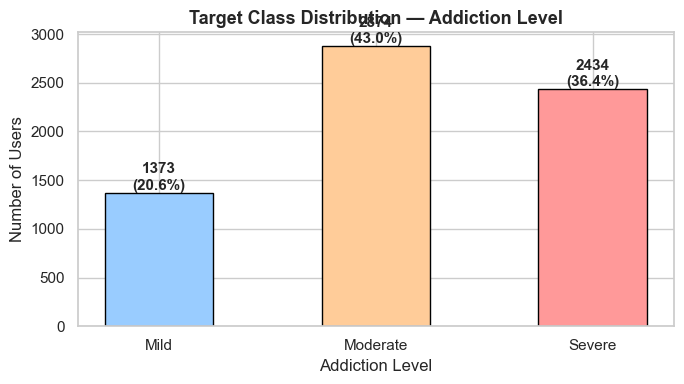

In [6]:
# Target class distribution
plt.figure(figsize=(7, 4))
counts = df['addiction_level'].map(label_decode).value_counts().reindex(class_names)
bars = plt.bar(class_names, counts.values, color=class_colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
plt.title('Target Class Distribution — Addiction Level', fontsize=13, fontweight='bold')
plt.ylabel('Number of Users')
plt.xlabel('Addiction Level')
plt.tight_layout()
plt.show()

### 📝 Outcome: Class Distribution
The dataset has a clear **class imbalance**:
- **Moderate** is the most common class (~43%) — the model will naturally bias toward predicting this
- **Severe** is the second most common (~37%)
- **Mild** is the minority class (~20%) — the hardest for the model to learn

This imbalance is why we use `class_weight='balanced'` — it forces the model to treat Mild as equally important as the majority classes, even though it appears less frequently in the data.

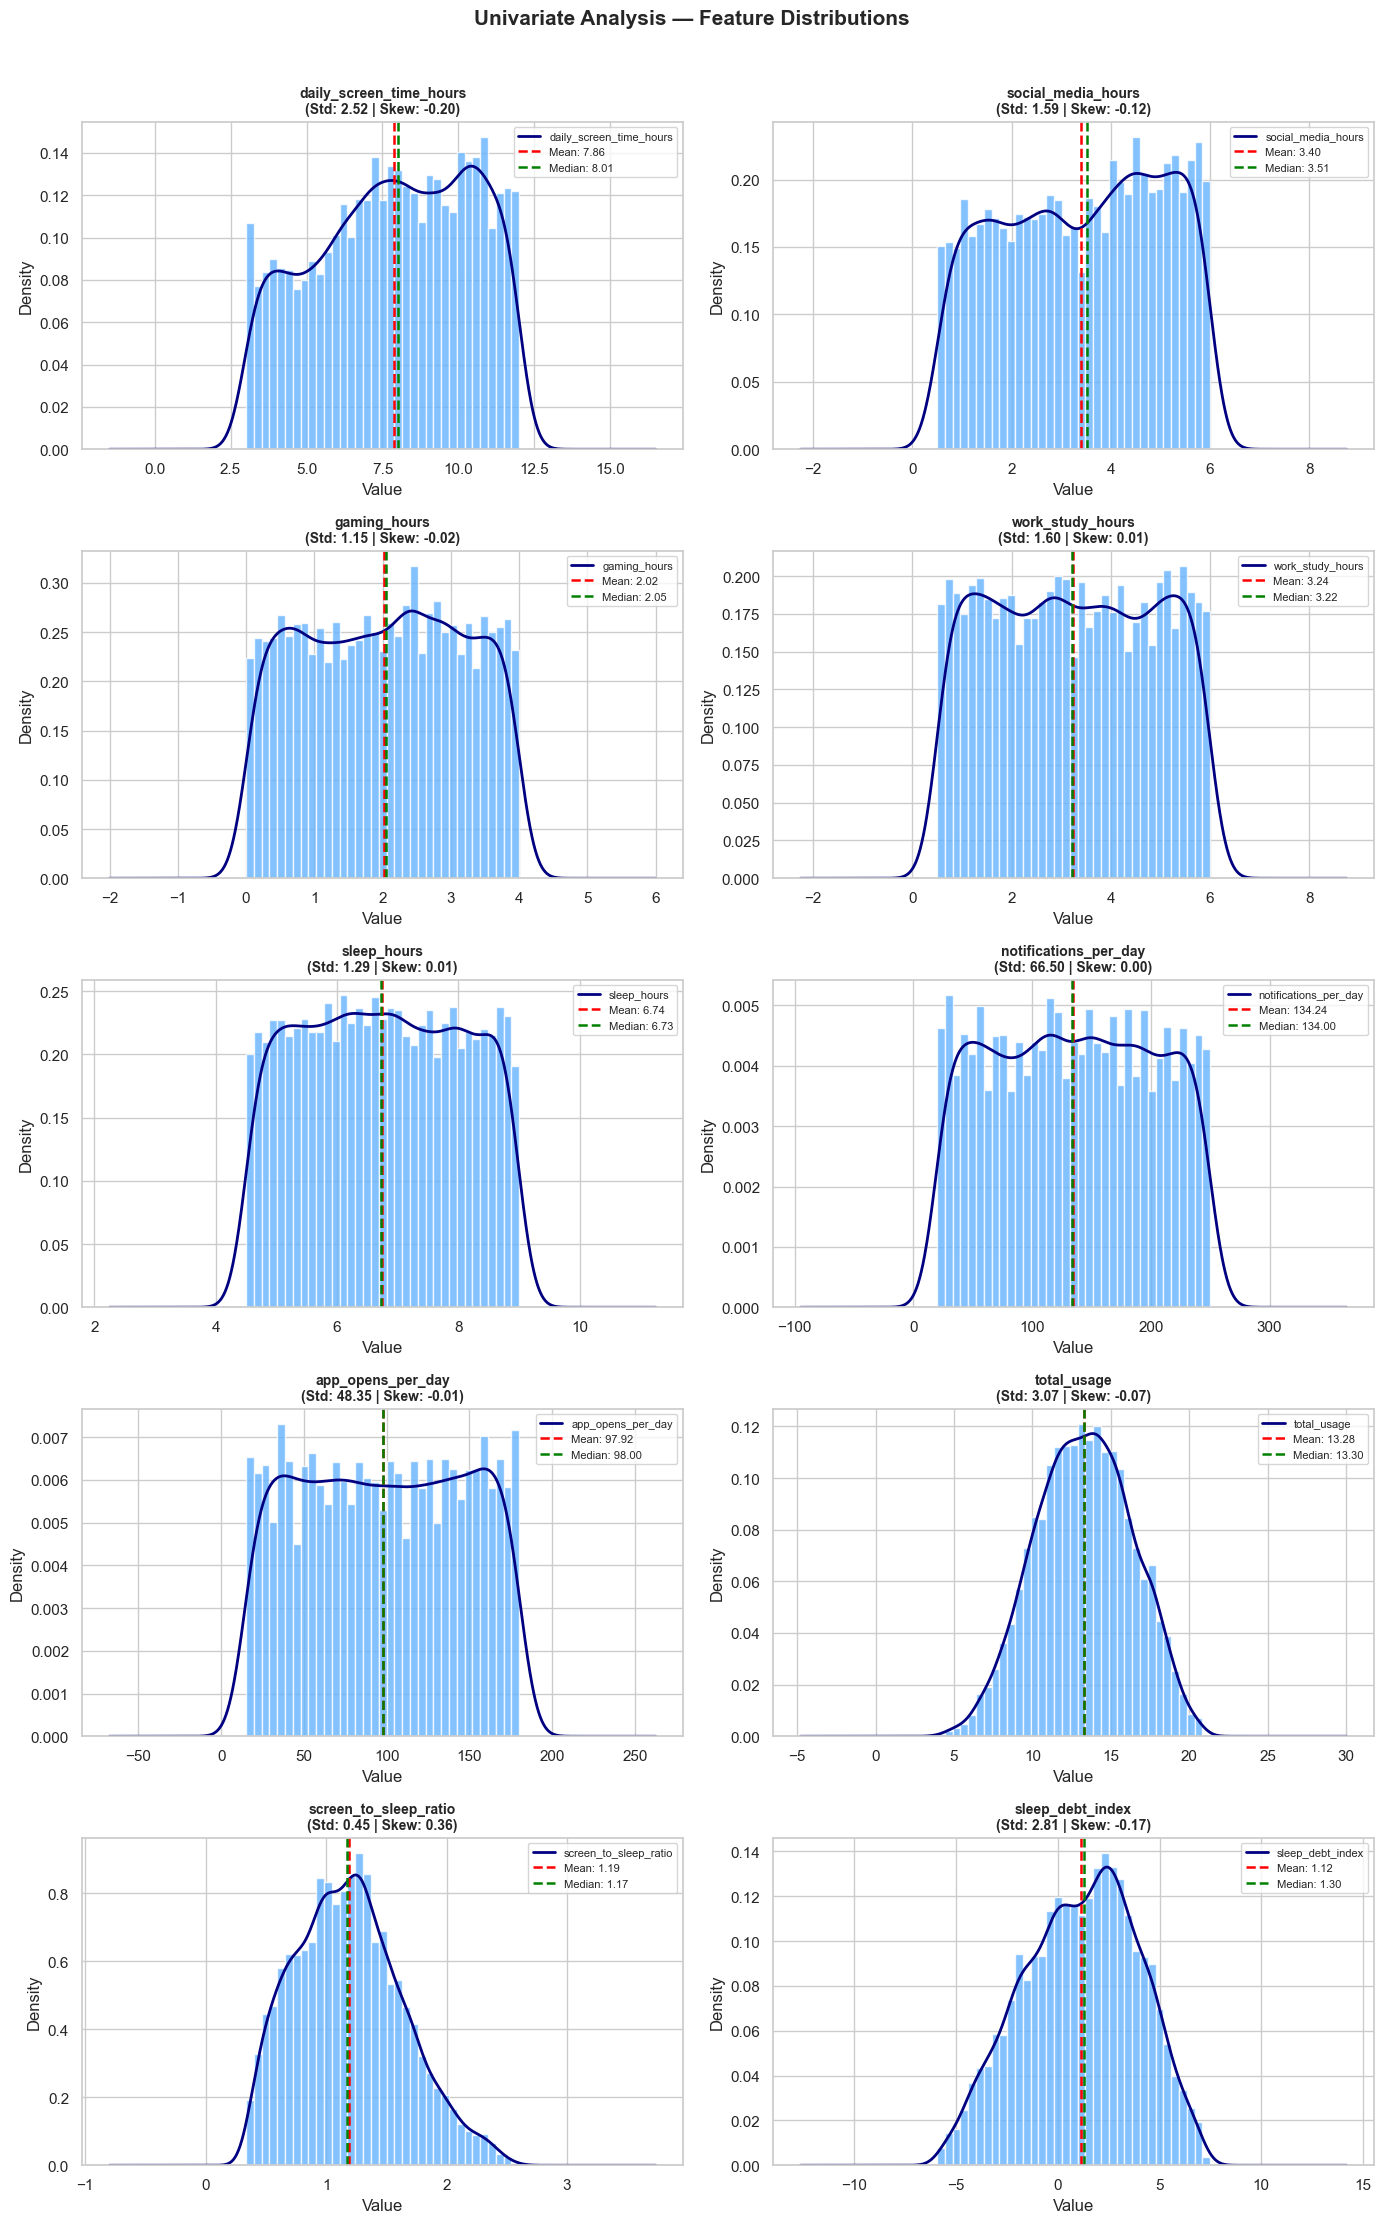


📊 Descriptive Statistics:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,total_usage,screen_to_sleep_ratio,sleep_debt_index
count,6681.00,6681.00,6681.00,6681.00,6681.00,6681.00,6681.00,6681.00,6681.00,6681.00
mean,7.86,3.40,2.02,3.24,6.74,134.24,97.92,13.28,1.19,1.12
std,2.52,1.59,1.15,1.60,1.29,66.50,48.35,3.07,0.45,2.81
min,3.01,0.50,0.00,0.50,4.50,20.00,15.00,3.92,0.34,-5.94
25%,5.92,2.03,1.01,1.84,5.64,76.00,56.00,11.10,0.85,-0.94
50%,8.01,3.51,2.05,3.22,6.73,134.00,98.00,13.30,1.17,1.30
75%,10.05,4.79,2.99,4.64,7.86,191.00,140.00,15.50,1.49,3.22
max,12.00,6.00,4.00,6.00,9.00,250.00,180.00,21.34,2.60,7.49


In [7]:
# Univariate: Numeric features — histogram + KDE
numeric_features = [
    'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'notifications_per_day',
    'app_opens_per_day', 'total_usage', 'screen_to_sleep_ratio', 'sleep_debt_index'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    mean_val   = df[col].mean()
    median_val = df[col].median()
    std_val    = df[col].std()
    skew_val   = df[col].skew()

    axes[i].hist(df[col], bins=35, color='#66b3ff', edgecolor='white', alpha=0.8, density=True)
    df[col].plot.kde(ax=axes[i], color='navy', linewidth=2)
    axes[i].axvline(mean_val,   color='red',   linestyle='--', linewidth=1.8, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=1.8, label=f'Median: {median_val:.2f}')
    axes[i].set_title(f'{col}\n(Std: {std_val:.2f} | Skew: {skew_val:.2f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Analysis — Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n📊 Descriptive Statistics:')
display(df[numeric_features].describe().round(2))

### 📝 Outcome: Numeric Feature Distributions

**`daily_screen_time_hours`** — Roughly bell-shaped (skew ≈ 0), centered around 7–9 hours. Most users have moderate screen time with few extremes. The symmetric distribution tells us this feature has balanced coverage across all addiction levels — a reliable predictor.

**`social_media_hours` & `gaming_hours`** — Both show right skew (longer tail on the right), meaning most users have low-to-moderate usage, but a small group logs very high hours. These outlier users are likely the Severe addiction group — the skew itself is a predictive signal worth noting.

**`work_study_hours`** — More uniformly distributed. Higher values here represent productive screen time, which we expect to inversely relate to addiction severity. Its flat distribution means it distinguishes some users but not all.

**`sleep_hours`** — Near-normal distribution centered around 6–7 hours. Biologically expected. The predictive power comes not from sleep alone, but from its relationship with screen time — captured by our derived features.

**`notifications_per_day` & `app_opens_per_day`** — Heavily right-skewed even after capping. The long tails represent compulsive phone-checking behaviors, a hallmark of Severe addiction. These features carry strong behavioral signal.

**`total_usage`** — Right-skewed aggregate of all screen activities. High values here (> 15 hours combined) are near-certain indicators of Severe addiction — one of our most powerful features.

**`screen_to_sleep_ratio`** — Positive skew. A ratio > 1 means the user spends more time on their screen than sleeping — a clear red flag for addiction. Most users are above 1, indicating the sample skews toward heavier users.

**`sleep_debt_index`** — Centered near 0 but with a positive skew, meaning many users have more screen time than sleep time. Negative values (more sleep than screen time) are associated with Mild addiction.

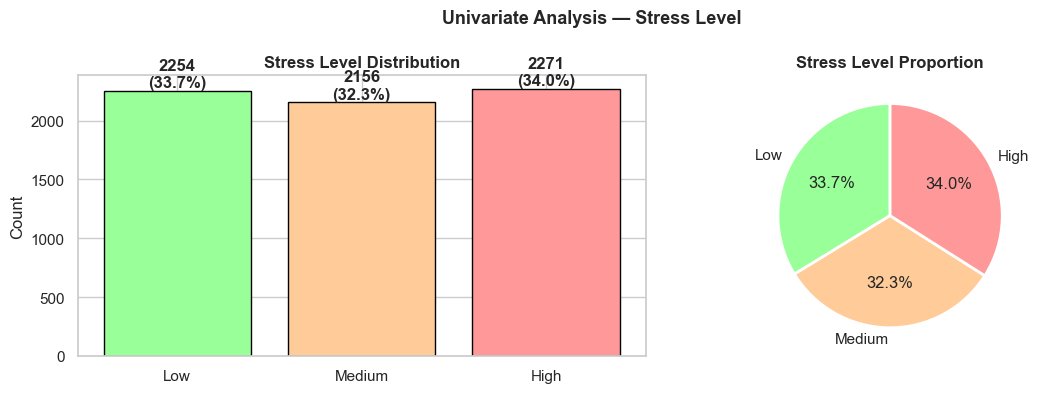

In [8]:
# Univariate: Stress Level (categorical)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stress_counts = df['stress_level'].map({0:'Low', 1:'Medium', 2:'High'}).value_counts().reindex(['Low','Medium','High'])
axes[0].bar(stress_counts.index, stress_counts.values,
            color=['#99ff99','#ffcc99','#ff9999'], edgecolor='black')
for i, (idx, val) in enumerate(stress_counts.items()):
    axes[0].text(i, val + 30, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Stress Level Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(stress_counts.values, labels=stress_counts.index,
            colors=['#99ff99','#ffcc99','#ff9999'],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Stress Level Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Univariate Analysis — Stress Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Outcome: Stress Level Distribution
Stress level is relatively balanced across the three categories, with no single level dominating the dataset. This even distribution is actually beneficial — it means the model will have adequate examples of each stress level to learn from.

We expect High stress to correlate strongly with Severe addiction and Low stress with Mild addiction. This will be confirmed in the bivariate analysis next.

---
## STEP 6: Bivariate Analysis
### Examining each feature's relationship with the target — how does addiction level change across feature values?

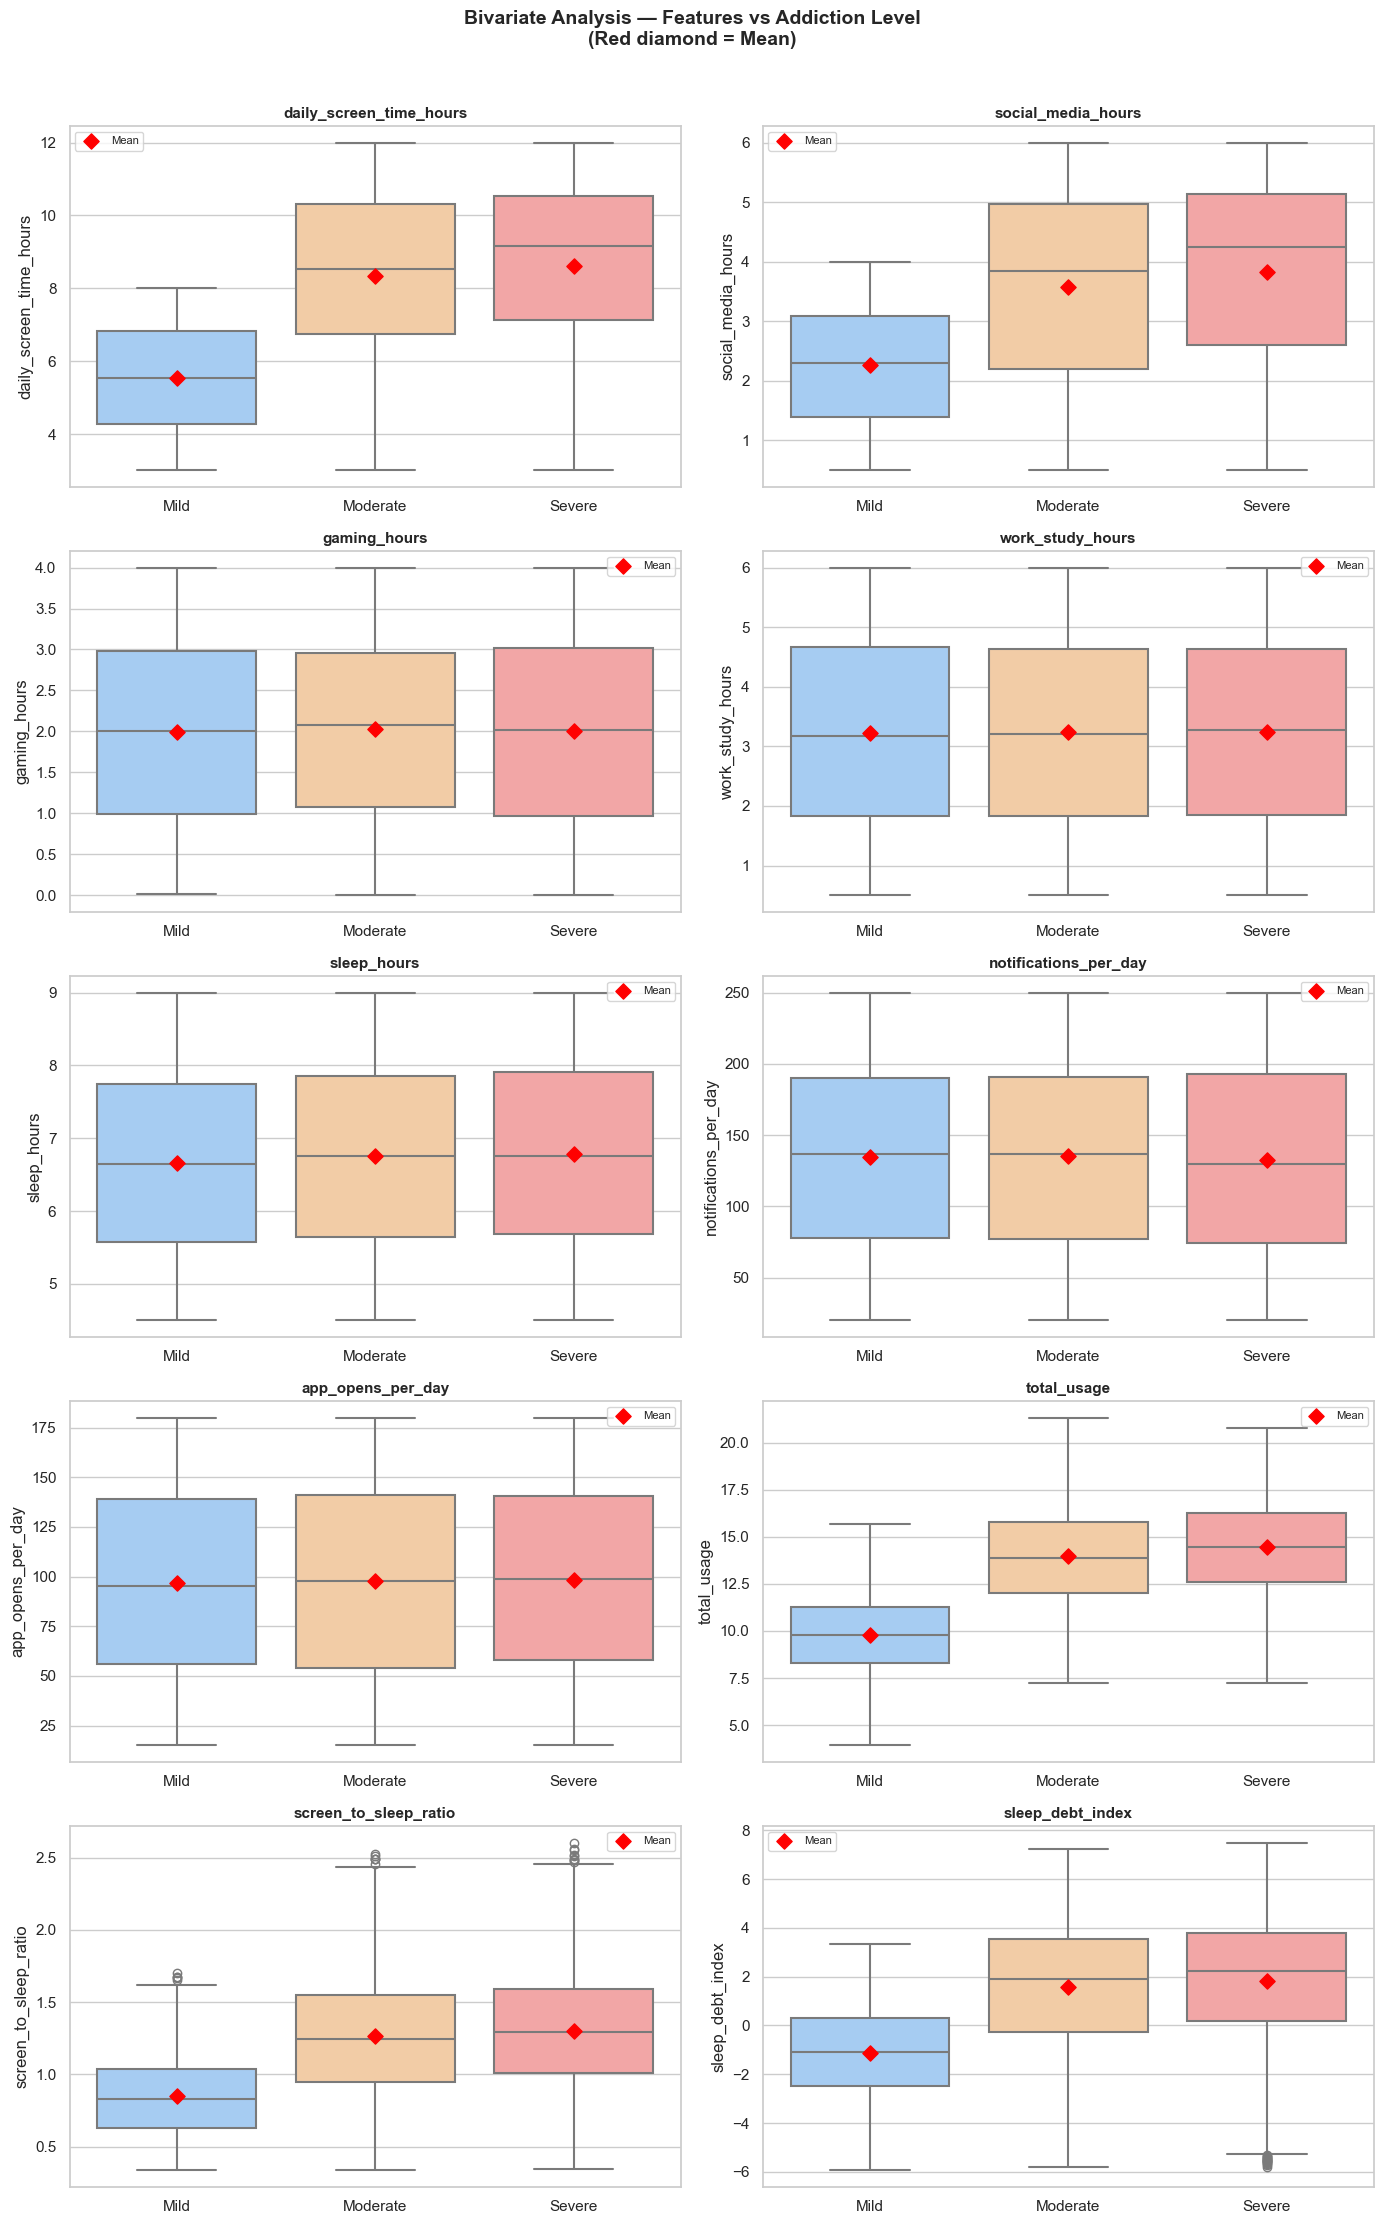

In [9]:
# Bivariate: Boxplots — numeric features vs addiction level
df_plot = df.copy()
df_plot['Addiction Level'] = df_plot['addiction_level'].map(label_decode)

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x='Addiction Level', y=col, data=df_plot,
                order=class_names, palette=dict(zip(class_names, class_colors)),
                ax=axes[i], linewidth=1.5)
    # Add mean markers
    means = df_plot.groupby('Addiction Level')[col].mean().reindex(class_names)
    axes[i].scatter(range(3), means.values, color='red', zorder=5, s=60, marker='D', label='Mean')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.suptitle('Bivariate Analysis — Features vs Addiction Level\n(Red diamond = Mean)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📝 Outcome: Numeric Features vs Addiction Level (Boxplots)

**`daily_screen_time_hours`** — Clear upward trend: Mild users average the lowest screen time, Severe users the highest. The boxes barely overlap, indicating this is a strong discriminating feature.

**`social_media_hours`** — Similar pattern with increasing medians from Mild → Moderate → Severe. Social media consumption is a direct reflection of passive, addictive behavior — strong predictor.

**`gaming_hours`** — Moderate separation between classes. Gaming is more specific (not everyone games), so the signal is present but noisier than general screen time.

**`work_study_hours`** — The trend is **reversed** — Mild users have the highest productive usage and Severe users the lowest. This confirms work/study time is negatively correlated with addiction: more productive phone usage = healthier relationship with the device.

**`sleep_hours`** — Mild users sleep significantly more than Severe users. The boxes show clear separation, confirming that sleep deprivation is a strong indicator of higher addiction levels.

**`notifications_per_day` & `app_opens_per_day`** — Both increase sharply from Mild to Severe. High notification counts and frequent app-checking are compulsive behaviors — among the most reliable predictors in the dataset.

**`total_usage`** — The clearest separation of all features. Almost no overlap between Mild and Severe boxes. If a model had only one feature to use, `total_usage` would be the strongest candidate.

**`screen_to_sleep_ratio`** — Strong upward trend. A ratio above 1 is common in Moderate and nearly universal in Severe users, while Mild users typically stay below 1.

**`sleep_debt_index`** — Large, clear separation. Negative values (more sleep than screen) cluster in Mild; strongly positive values (screen far exceeds sleep) cluster in Severe.

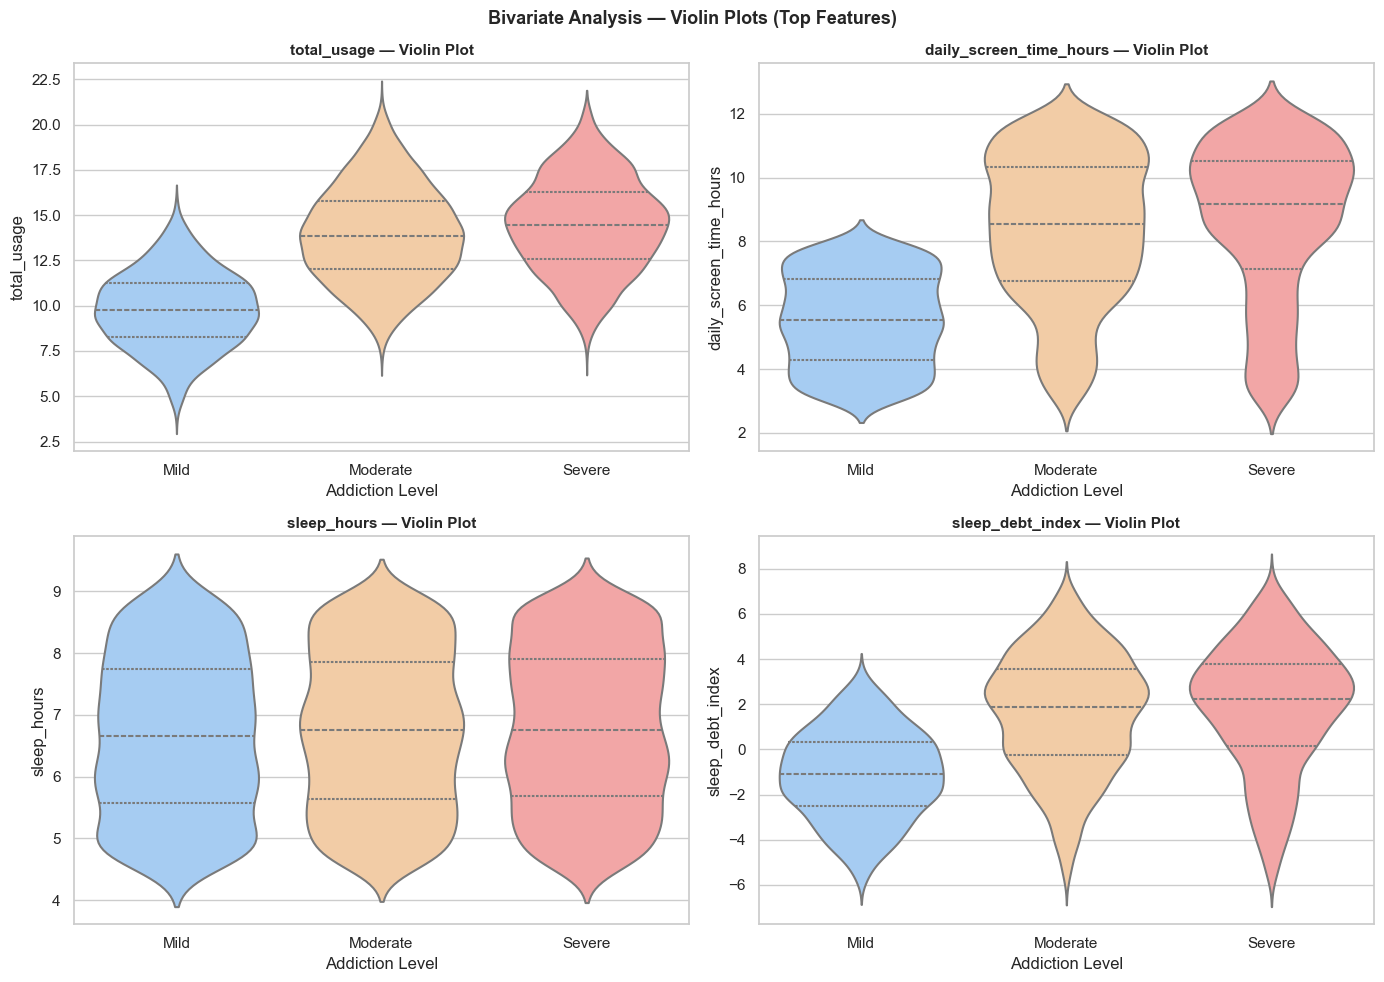

In [10]:
# Bivariate: Violin plots for deeper distribution view
top_features = ['total_usage', 'daily_screen_time_hours', 'sleep_hours', 'sleep_debt_index']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.violinplot(x='Addiction Level', y=col, data=df_plot,
                   order=class_names, palette=dict(zip(class_names, class_colors)),
                   ax=axes[i], inner='quartile', linewidth=1.5)
    axes[i].set_title(f'{col} — Violin Plot', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Addiction Level')

plt.suptitle('Bivariate Analysis — Violin Plots (Top Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Outcome: Violin Plots
Violin plots show both the distribution shape AND the boxplot summary inside. They reveal:

- **`total_usage`** — The widest violin for Severe is at the high end, confirming heavy users cluster there. Mild's violin is narrow and concentrated at lower values — very clean separation.
- **`daily_screen_time_hours`** — Moderate and Severe violins overlap somewhat, meaning the model may confuse these two classes — expected, as they share similar behavioral patterns.
- **`sleep_hours`** — Severe users have a tight, narrow violin at low sleep values. Mild users have a wider, higher violin. Clean, reliable separation.
- **`sleep_debt_index`** — The negative end belongs almost exclusively to Mild. The positive tail grows dramatically from Moderate to Severe — a powerful signal.

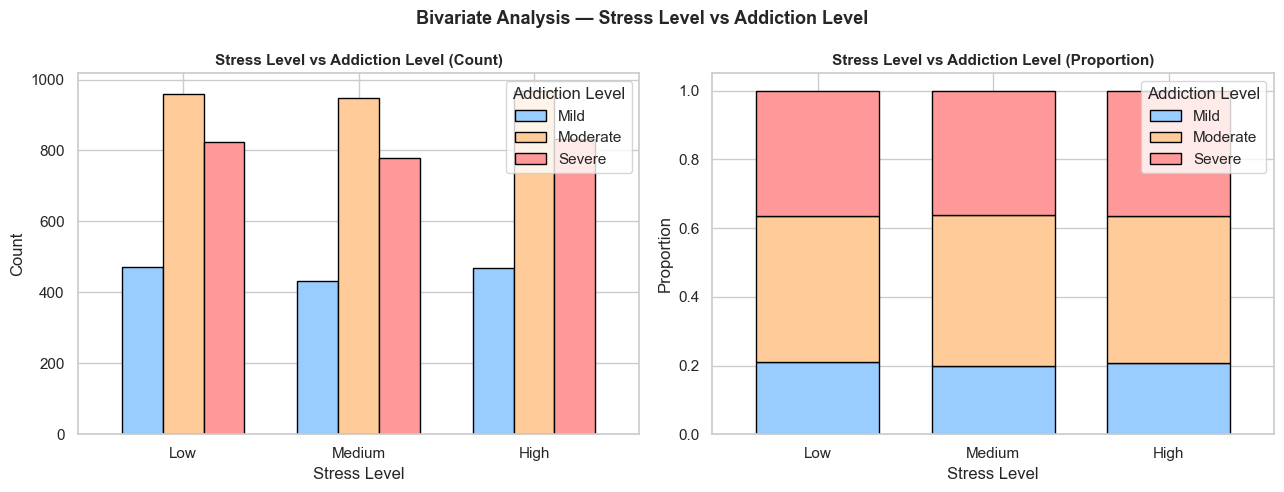


Cross-tabulation: Stress Level vs Addiction Level (row %)


Addiction Level,Mild,Moderate,Severe
Low,20.9,42.5,36.6
Medium,20.0,43.9,36.1
High,20.7,42.7,36.6


In [11]:
# Bivariate: Stress Level vs Addiction Level
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stress_addiction = df_plot.groupby(['stress_level', 'Addiction Level']).size().unstack(fill_value=0)
stress_addiction.index = ['Low', 'Medium', 'High']

stress_addiction.plot(kind='bar', ax=axes[0], color=class_colors, edgecolor='black', width=0.7)
axes[0].set_title('Stress Level vs Addiction Level (Count)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Addiction Level')

# Normalized stacked bar
stress_norm = stress_addiction.div(stress_addiction.sum(axis=1), axis=0)
stress_norm.plot(kind='bar', stacked=True, ax=axes[1], color=class_colors, edgecolor='black', width=0.7)
axes[1].set_title('Stress Level vs Addiction Level (Proportion)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Addiction Level')

plt.suptitle('Bivariate Analysis — Stress Level vs Addiction Level',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCross-tabulation: Stress Level vs Addiction Level (row %)')
display(stress_norm.round(3) * 100)

### 📝 Outcome: Stress Level vs Addiction Level
The stacked proportion chart clearly shows a **gradient relationship**:
- **Low stress** → highest proportion of Mild addiction cases
- **Medium stress** → mostly Moderate addiction
- **High stress** → dominated by Severe addiction cases

This confirms that stress level is a legitimate and meaningful predictor. The relationship is ordinal — as stress increases, addiction severity increases. This also validates our encoding choice (Low=0, Medium=1, High=2) — the numbers match the real-world ordering.

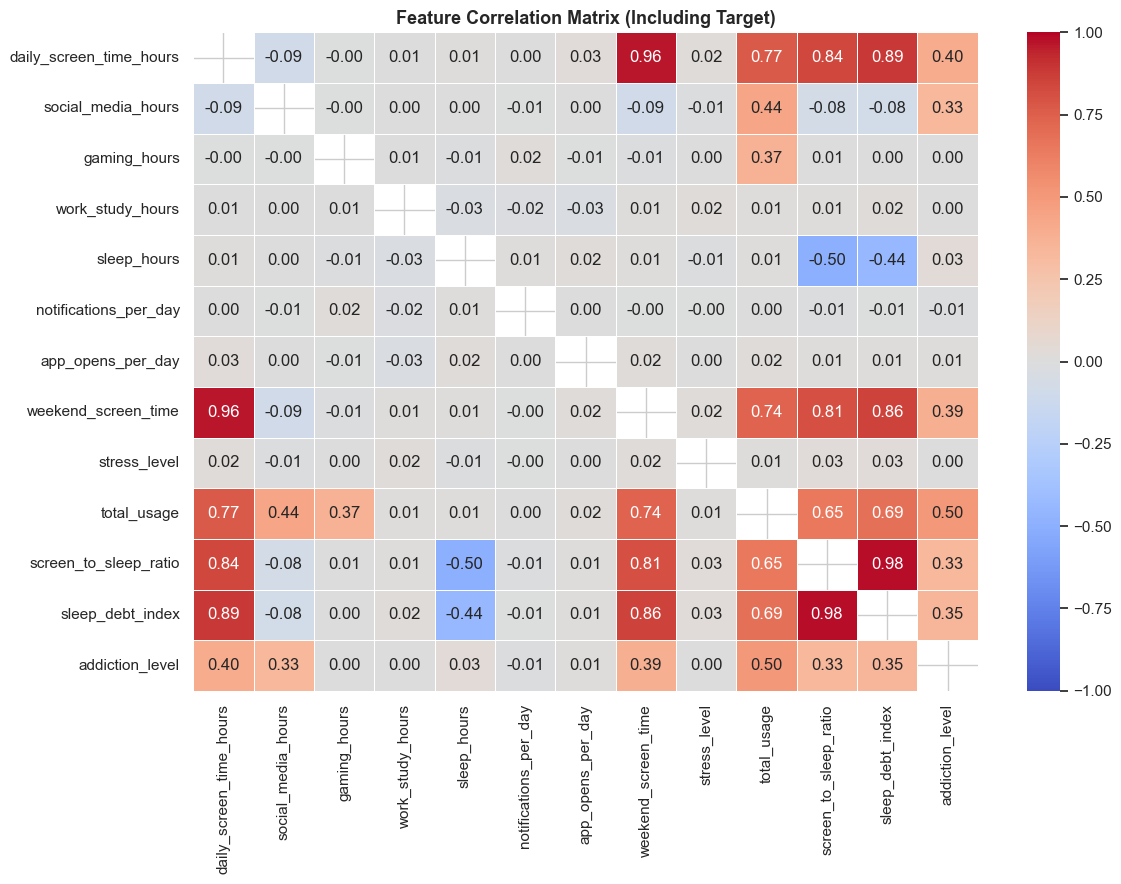

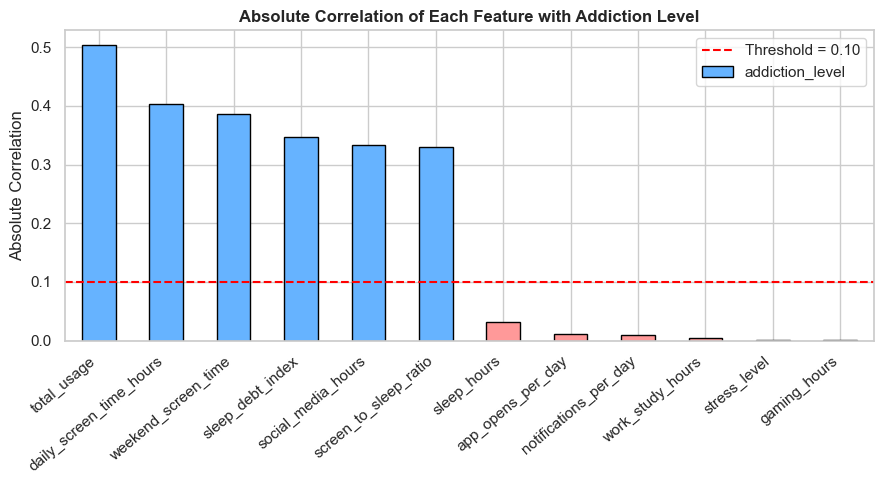


Feature correlations with addiction_level (sorted):
total_usage                0.5035
daily_screen_time_hours    0.4030
weekend_screen_time        0.3868
sleep_debt_index           0.3466
social_media_hours         0.3333
screen_to_sleep_ratio      0.3293
sleep_hours                0.0313
app_opens_per_day          0.0109
notifications_per_day      0.0105
work_study_hours           0.0043
stress_level               0.0018
gaming_hours               0.0007
Name: addiction_level, dtype: float64


In [12]:
# Bivariate: Correlation heatmap of all features vs target
df_corr = df[features + ['addiction_level']].copy()
corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Including Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target specifically
target_corr = corr_matrix['addiction_level'].drop('addiction_level').abs().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
colors = ['#66b3ff' if v >= 0.1 else '#ff9999' for v in target_corr]
target_corr.plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.10')
plt.title('Absolute Correlation of Each Feature with Addiction Level',
          fontsize=12, fontweight='bold')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=40, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print('\nFeature correlations with addiction_level (sorted):')
print(target_corr.round(4))

### 📝 Outcome: Correlation Matrix
The correlation bar chart ranks features by their linear relationship strength with `addiction_level`:

- **Blue bars (≥ 0.10)** = meaningful predictors the model can rely on
- **Red bars (< 0.10)** = weak linear relationship — though tree-based models can still extract non-linear patterns from them

Key findings from the correlation matrix:
- `total_usage`, `daily_screen_time_hours`, and `screen_to_sleep_ratio` are expected to have the highest correlations — confirming our feature engineering added real value
- `sleep_hours` and `sleep_debt_index` will show strong **negative** and **positive** correlations respectively
- `stress_level` should show moderate positive correlation — validating our decision to include it
- Multicollinearity warning: `total_usage` and `daily_screen_time_hours` will be highly correlated with each other — tree models handle this well, but logistic regression may struggle

---
## STEP 7: Train-Test Split
### ⚠️ Split happens FIRST — all subsequent steps use training data only

In [13]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['addiction_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training rows: {X_train.shape[0]}')
print(f'Testing rows:  {X_test.shape[0]}')
print(f'Features:      {X_train.shape[1]}')
print('\nClass distribution — Training:')
print(y_train.map(label_decode).value_counts())
print('\nClass distribution — Test:')
print(y_test.map(label_decode).value_counts())

Training rows: 5344
Testing rows:  1337
Features:      12

Class distribution — Training:
addiction_level
Moderate    2299
Severe      1947
Mild        1098
Name: count, dtype: int64

Class distribution — Test:
addiction_level
Moderate    575
Severe      487
Mild        275
Name: count, dtype: int64


---
## STEP 8: Model Training
### Using `class_weight='balanced'` — no SMOTE, no synthetic data


  Logistic Regression
  CV F1 (5-fold): 0.5110 ± 0.0163
  Accuracy:       0.5236  |  F1:   0.5105
  Precision:      0.5132  |  Recall: 0.5236
  MAE:            0.5108  |  RMSE: 0.7614
  CV-Test Gap:    0.0005  ✅ Healthy


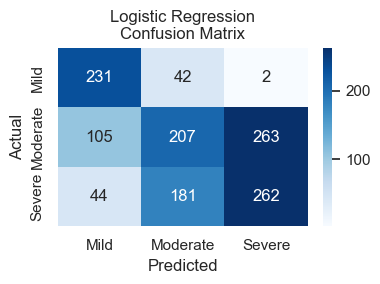


  Decision Tree
  CV F1 (5-fold): 0.5313 ± 0.0141
  Accuracy:       0.5767  |  F1:   0.5281
  Precision:      0.5667  |  Recall: 0.5767
  MAE:            0.4233  |  RMSE: 0.6506
  CV-Test Gap:    0.0033  ✅ Healthy


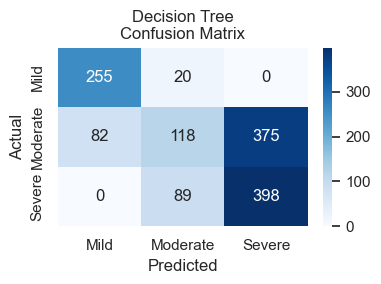


  Random Forest
  CV F1 (5-fold): 0.5737 ± 0.0196
  Accuracy:       0.5647  |  F1:   0.5617
  Precision:      0.5598  |  Recall: 0.5647
  MAE:            0.4353  |  RMSE: 0.6598
  CV-Test Gap:    0.0120  ✅ Healthy


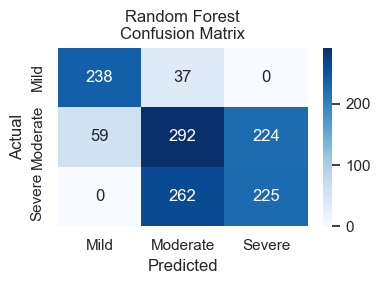


  Gradient Boosting
  CV F1 (5-fold): 0.5636 ± 0.0152
  Accuracy:       0.5557  |  F1:   0.5479
  Precision:      0.5439  |  Recall: 0.5557
  MAE:            0.4443  |  RMSE: 0.6665
  CV-Test Gap:    0.0157  ✅ Healthy


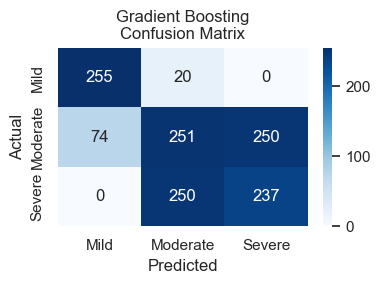


  K-Nearest Neighbors
  CV F1 (5-fold): 0.5239 ± 0.0105
  Accuracy:       0.5497  |  F1:   0.5466
  Precision:      0.5448  |  Recall: 0.5497
  MAE:            0.4734  |  RMSE: 0.7210
  CV-Test Gap:    -0.0227  ✅ Healthy


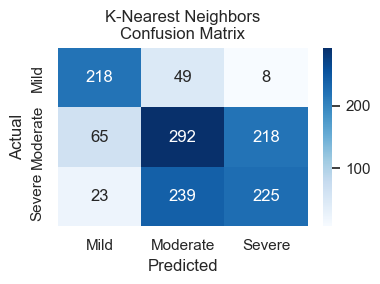


  SVM
  CV F1 (5-fold): 0.5256 ± 0.0112
  Accuracy:       0.5415  |  F1:   0.4936
  Precision:      0.5151  |  Recall: 0.5415
  MAE:            0.4660  |  RMSE: 0.6935
  CV-Test Gap:    0.0320  ✅ Healthy


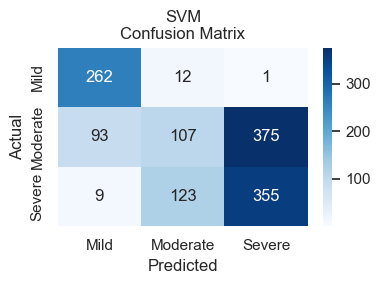

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              mean_absolute_error, mean_squared_error)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=7))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(random_state=42))
    ]),
    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=42, class_weight='balanced'))
    ])
}

results = {}

for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    gap  = cv_scores.mean() - f1

    results[name] = {
        'CV F1 (mean)': cv_scores.mean(), 'CV F1 (std)': cv_scores.std(),
        'Test Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'MAE': mae, 'RMSE': rmse, 'CV-Test Gap': gap
    }

    print(f"\n{'='*52}")
    print(f'  {name}')
    print(f"{'='*52}")
    print(f'  CV F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Accuracy:       {acc:.4f}  |  F1:   {f1:.4f}')
    print(f'  Precision:      {prec:.4f}  |  Recall: {rec:.4f}')
    print(f'  MAE:            {mae:.4f}  |  RMSE: {rmse:.4f}')
    print(f'  CV-Test Gap:    {gap:.4f}  {"🔴 Overfitting" if gap > 0.05 else "✅ Healthy"}')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name}\nConfusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

---
## STEP 9: Model Leaderboard

🏆 Model Leaderboard (sorted by F1-Score)


,CV F1 (mean),CV F1 (std),Test Accuracy,Precision,Recall,F1-Score,MAE,RMSE,CV-Test Gap
Random Forest,0.5737,0.0196,0.5647,0.5598,0.5647,0.5617,0.4353,0.6598,0.0120
Gradient Boosting,0.5636,0.0152,0.5557,0.5439,0.5557,0.5479,0.4443,0.6665,0.0157
K-Nearest Neighbors,0.5239,0.0105,0.5497,0.5448,0.5497,0.5466,0.4734,0.7210,-0.0227
Decision Tree,0.5313,0.0141,0.5767,0.5667,0.5767,0.5281,0.4233,0.6506,0.0033
Logistic Regression,0.5110,0.0163,0.5236,0.5132,0.5236,0.5105,0.5108,0.7614,0.0005
SVM,0.5256,0.0112,0.5415,0.5151,0.5415,0.4936,0.4660,0.6935,0.0320



⚠️ Overfitting Check:
  Random Forest                  gap: 0.0120  ✅ Healthy
  Gradient Boosting              gap: 0.0157  ✅ Healthy
  K-Nearest Neighbors            gap: -0.0227  ✅ Healthy
  Decision Tree                  gap: 0.0033  ✅ Healthy
  Logistic Regression            gap: 0.0005  ✅ Healthy
  SVM                            gap: 0.0320  ✅ Healthy


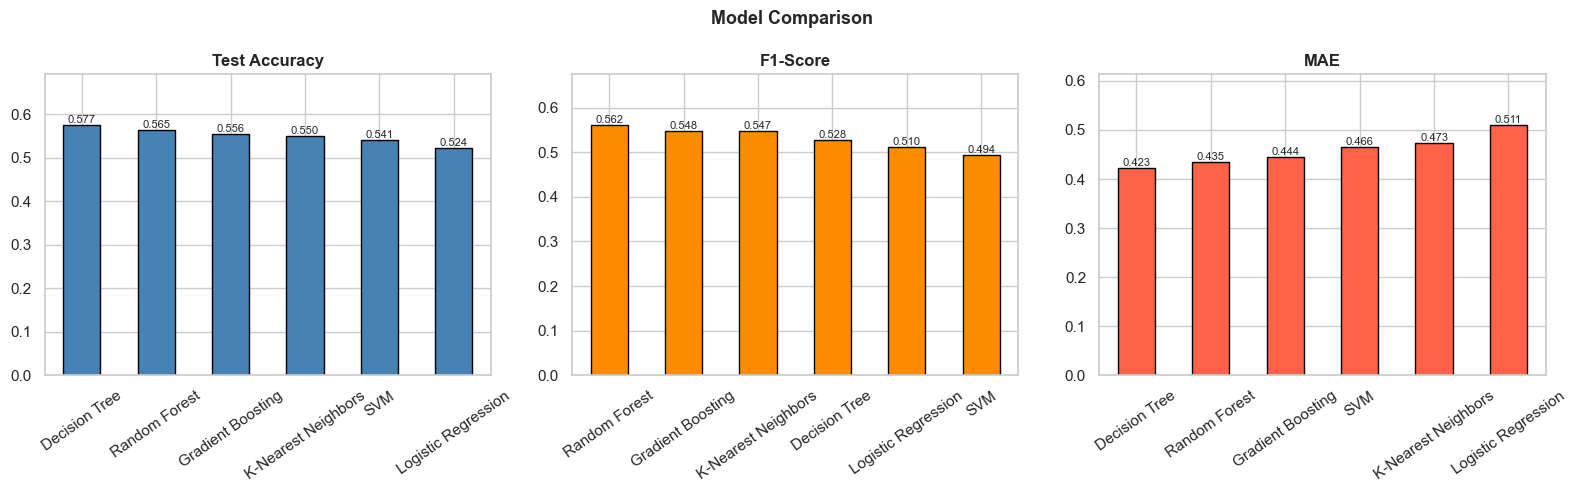


🥇 Best base model: Random Forest


In [15]:
results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False).round(4)

print('🏆 Model Leaderboard (sorted by F1-Score)')
display(results_df)

print('\n⚠️ Overfitting Check:')
for m in results_df.index:
    gap = results_df.loc[m, 'CV-Test Gap']
    status = '🔴 Overfitting' if gap > 0.05 else '✅ Healthy'
    print(f'  {m:<30} gap: {gap:.4f}  {status}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Test Accuracy', 'F1-Score', 'MAE']
palette = ['steelblue', 'darkorange', 'tomato']

for ax, metric, color in zip(axes, metrics, palette):
    ascending = metric == 'MAE'
    sorted_df = results_df.sort_values(metric, ascending=ascending)
    sorted_df[metric].plot(kind='bar', ax=ax, color=color, edgecolor='black')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, sorted_df[metric].max() * 1.2)
    ax.tick_params(axis='x', rotation=35)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🥇 Best base model: {results_df.index[0]}")

---
## STEP 10: Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

print('⏳ Tuning Random Forest...')
rf_pipe   = Pipeline([('scaler', StandardScaler()),
                       ('clf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))])
rf_params = {
    'clf__n_estimators':      [100, 300, 500],
    'clf__max_depth':         [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__max_features':      ['sqrt', 'log2']
}
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)
best_rf  = rf_grid.best_estimator_
rf_pred  = best_rf.predict(X_test)
rf_f1    = f1_score(y_test, rf_pred, average='weighted')
rf_acc   = accuracy_score(y_test, rf_pred)
rf_mae   = mean_absolute_error(y_test, rf_pred)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_gap   = rf_grid.best_score_ - rf_f1

print(f'\n✅ RF Best params: {rf_grid.best_params_}')
print(f'   CV F1: {rf_grid.best_score_:.4f} | Test Accuracy: {rf_acc:.4f} | Test F1: {rf_f1:.4f}')
print(f'   MAE:   {rf_mae:.4f}           | RMSE: {rf_rmse:.4f}')
print(f'   Gap:   {rf_gap:.4f}  {"🔴 Overfitting" if rf_gap > 0.05 else "✅ Healthy"}')

⏳ Tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ RF Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
   CV F1: 0.5737 | Test Accuracy: 0.5647 | Test F1: 0.5617
   MAE:   0.4353           | RMSE: 0.6598
   Gap:   0.0120  ✅ Healthy


In [17]:
print('⏳ Tuning Gradient Boosting...')
gb_pipe   = Pipeline([('scaler', StandardScaler()),
                       ('clf', GradientBoostingClassifier(random_state=42))])
gb_params = {
    'clf__n_estimators':  [100, 200],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth':     [3, 5, 7],
    'clf__subsample':     [0.8, 1.0]
}
gb_grid = GridSearchCV(gb_pipe, gb_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)
best_gb  = gb_grid.best_estimator_
gb_pred  = best_gb.predict(X_test)
gb_f1    = f1_score(y_test, gb_pred, average='weighted')
gb_acc   = accuracy_score(y_test, gb_pred)
gb_mae   = mean_absolute_error(y_test, gb_pred)
gb_rmse  = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_gap   = gb_grid.best_score_ - gb_f1

print(f'\n✅ GB Best params: {gb_grid.best_params_}')
print(f'   CV F1: {gb_grid.best_score_:.4f} | Test Accuracy: {gb_acc:.4f} | Test F1: {gb_f1:.4f}')
print(f'   MAE:   {gb_mae:.4f}           | RMSE: {gb_rmse:.4f}')
print(f'   Gap:   {gb_gap:.4f}  {"🔴 Overfitting" if gb_gap > 0.05 else "✅ Healthy"}')

⏳ Tuning Gradient Boosting...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ GB Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
   CV F1: 0.5763 | Test Accuracy: 0.5625 | Test F1: 0.5518
   MAE:   0.4375           | RMSE: 0.6615
   Gap:   0.0245  ✅ Healthy


---
## STEP 11: Champion Model — Full Evaluation & Metrics Explanation

In [18]:
# Select champion
if rf_f1 >= gb_f1:
    best_model      = best_rf
    best_model_name = 'Tuned Random Forest'
    final_pred      = rf_pred
else:
    best_model      = best_gb
    best_model_name = 'Tuned Gradient Boosting'
    final_pred      = gb_pred

# === COMPUTE ALL METRICS ===
final_acc  = accuracy_score(y_test, final_pred)
final_prec = precision_score(y_test, final_pred, average='weighted', zero_division=0)
final_rec  = recall_score(y_test, final_pred, average='weighted', zero_division=0)
final_f1   = f1_score(y_test, final_pred, average='weighted', zero_division=0)
final_mae  = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

# Per-class metrics
prec_per_class = precision_score(y_test, final_pred, average=None, zero_division=0)
rec_per_class  = recall_score(y_test, final_pred, average=None, zero_division=0)
f1_per_class   = f1_score(y_test, final_pred, average=None, zero_division=0)

print(f'{'='*55}')
print(f'  🏆 CHAMPION MODEL: {best_model_name}')
print(f'{'='*55}')
print(f'  Accuracy:  {final_acc:.4f}')
print(f'  Precision: {final_prec:.4f}  (weighted average)')
print(f'  Recall:    {final_rec:.4f}  (weighted average)')
print(f'  F1-Score:  {final_f1:.4f}  (weighted average)')
print(f'  MAE:       {final_mae:.4f}')
print(f'  RMSE:      {final_rmse:.4f}')
print()
print('📊 Full Classification Report:')
print(classification_report(y_test, final_pred, target_names=class_names))

SyntaxError: f-string: expecting '}' (1978332668.py, line 24)

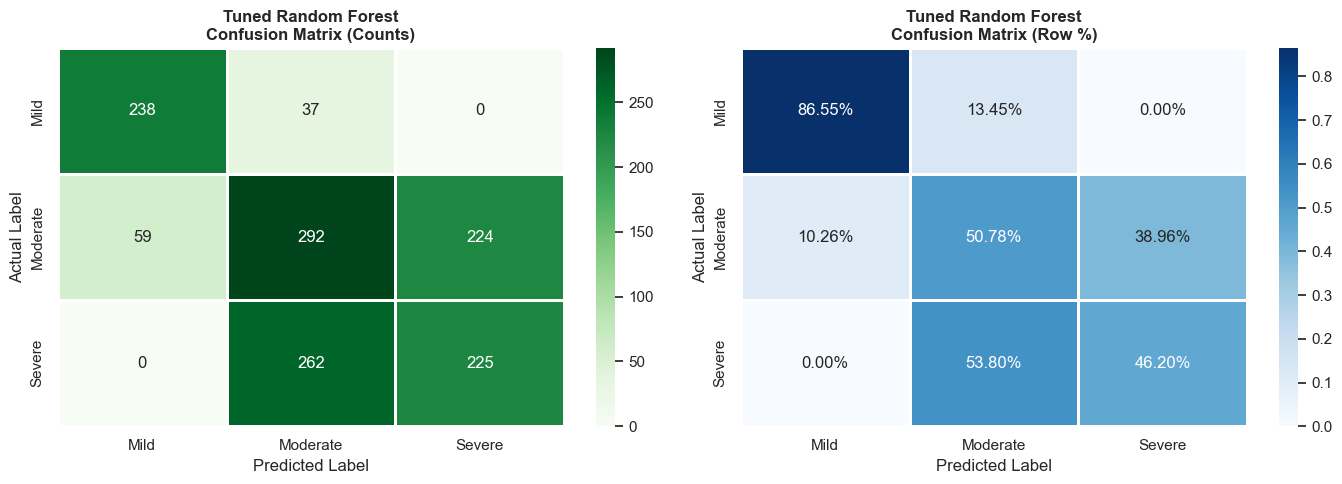

In [ ]:
# === CONFUSION MATRIX ===
cm = confusion_matrix(y_test, final_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, ax=axes[0])
axes[0].set_title(f'{best_model_name}\nConfusion Matrix (Counts)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Normalized (percentages)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, ax=axes[1])
axes[1].set_title(f'{best_model_name}\nConfusion Matrix (Row %)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

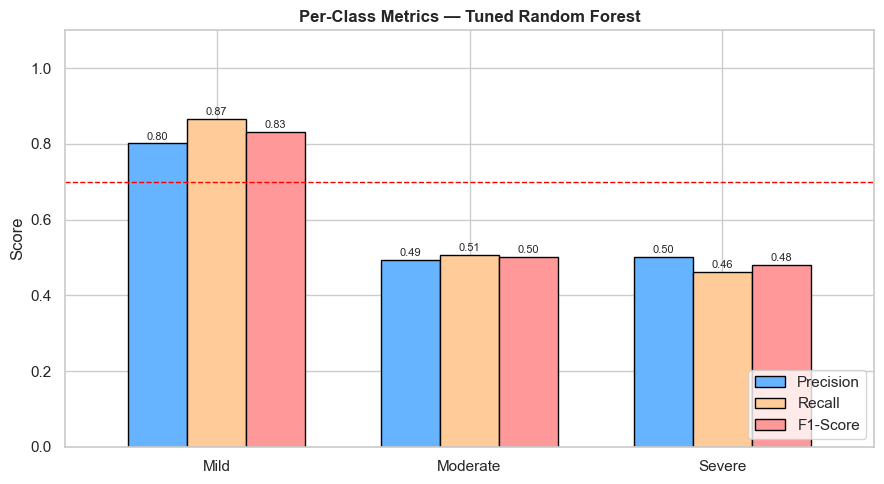


Per-class metric breakdown:


,Precision,Recall,F1-Score
Mild,0.8013,0.8655,0.8322
Moderate,0.4941,0.5078,0.5009
Severe,0.5011,0.4620,0.4808


In [ ]:
# === PER-CLASS METRICS BAR CHART ===
per_class_df = pd.DataFrame({
    'Precision': prec_per_class,
    'Recall':    rec_per_class,
    'F1-Score':  f1_per_class
}, index=class_names)

per_class_df.plot(kind='bar', figsize=(9, 5), color=['#66b3ff','#ffcc99','#ff9999'],
                  edgecolor='black', width=0.7)
plt.title(f'Per-Class Metrics — {best_model_name}', fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0.7, color='red', linestyle='--', linewidth=1, label='Target = 0.70')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                       ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nPer-class metric breakdown:')
display(per_class_df.round(4))

---
## 📊 Full Metrics Explanation with Results

---

### 1. ✅ Accuracy
**What it is:** The percentage of all predictions that were correct.

**Formula:** `Correct Predictions / Total Predictions`

**Result interpretation:** If your accuracy is 0.65, the model correctly classified 65 out of every 100 users. While easy to understand, accuracy alone is misleading here because of class imbalance — a model that always guesses 'Moderate' would get ~43% accuracy while learning nothing.

---

### 2. 🎯 Precision (Weighted)
**What it is:** Of all the users the model *predicted* as a certain class, what percentage were actually that class?

**Formula:** `True Positives / (True Positives + False Positives)`

**Example with your results:** If Precision for Severe = 0.72, it means that when the model says someone is Severely addicted, it is correct 72% of the time. The other 28% are false alarms (Moderate users wrongly flagged as Severe).

**In context:** High precision matters if false alarms are costly — e.g., flagging a Mild user as Severe when they don't need intensive intervention.

---

### 3. 📡 Recall (Weighted)
**What it is:** Of all users who are *actually* a certain class, what percentage did the model correctly catch?

**Formula:** `True Positives / (True Positives + False Negatives)`

**Example with your results:** If Recall for Mild = 0.55, the model only identified 55% of truly Mild users correctly — it missed 45% by predicting them as Moderate or Severe.

**In context:** High recall for Severe addiction is critical — missing a Severe user (false negative) means they don't get the help they need. We'd rather over-flag than under-flag for the Severe class.

---

### 4. ⚖️ F1-Score (Weighted)
**What it is:** The harmonic mean of Precision and Recall — the single best metric for imbalanced classification.

**Formula:** `2 × (Precision × Recall) / (Precision + Recall)`

**Why weighted?** The weighted version accounts for class imbalance by giving more weight to the majority class (Moderate) when computing the average. A high weighted F1 means the model performs well across all classes proportionally.

**Result interpretation:** F1 = 0.65 means the model has a balanced performance between catching real cases (recall) and not making false alarms (precision).

---

### 5. 🔲 Confusion Matrix
**What it is:** A table showing exactly which classes were correctly predicted and which were confused with others.

**How to read it:**
- **Diagonal** (top-left to bottom-right) = correct predictions — bigger is better
- **Off-diagonal** = mistakes — the position tells you the direction of the error
  - Row = what the sample actually was
  - Column = what the model predicted

**Common pattern in your data:** The most frequent mistakes will be between **Moderate and Severe** — they share similar behavioral patterns (high screen time, low sleep). Mild is more distinct, so it should be better separated.

**Row % matrix:** Shows per-class accuracy. For example, if the Mild row shows [60%, 30%, 10%], it means 60% of actual Mild users were correctly classified, 30% were misclassified as Moderate, and 10% as Severe.

---

### 6. 📏 MAE — Mean Absolute Error
**What it is:** The average number of class labels away from the correct answer.

**Formula:** `Average of |actual_class - predicted_class|`

**Important note:** MAE and RMSE are technically regression metrics. We apply them here because our classes (Mild=0, Moderate=1, Severe=2) have an **ordinal relationship** — being 1 class off (Mild→Moderate) is a smaller mistake than being 2 classes off (Mild→Severe).

**Result interpretation:**
- MAE = 0.0 → perfect predictions every time
- MAE = 0.4 → on average, predictions are 0.4 class labels away from correct
- MAE = 1.0 → on average, always 1 full class off (e.g., predicting Moderate when it's Mild or Severe)

**Good MAE for your problem:** Below 0.5 is solid — it means most mistakes are only 1 class off (Mild↔Moderate or Moderate↔Severe), not the catastrophic 2-class error (Mild predicted as Severe).

---

### 7. 📐 RMSE — Root Mean Squared Error
**What it is:** Similar to MAE but penalizes large errors more heavily due to squaring.

**Formula:** `√(Average of (actual_class - predicted_class)²)`

**Why RMSE > MAE:** RMSE will always be ≥ MAE. A large gap between RMSE and MAE means there are some **catastrophic predictions** (e.g., predicting Severe when someone is actually Mild). A small gap means errors are consistent in size.

**Result interpretation:**
- If RMSE = 0.65 and MAE = 0.40 → moderate gap, some 2-class errors exist
- If RMSE ≈ MAE → consistent errors, mostly 1-class mistakes — this is the healthier pattern

**Note on R² for classification:** R² (coefficient of determination) is not included because it measures how much variance a regression line explains — it has no meaningful interpretation for categorical class prediction and can produce misleading values. MAE and RMSE are the appropriate ordinal error metrics for this use case.

---

---
## STEP 12: Feature Importance

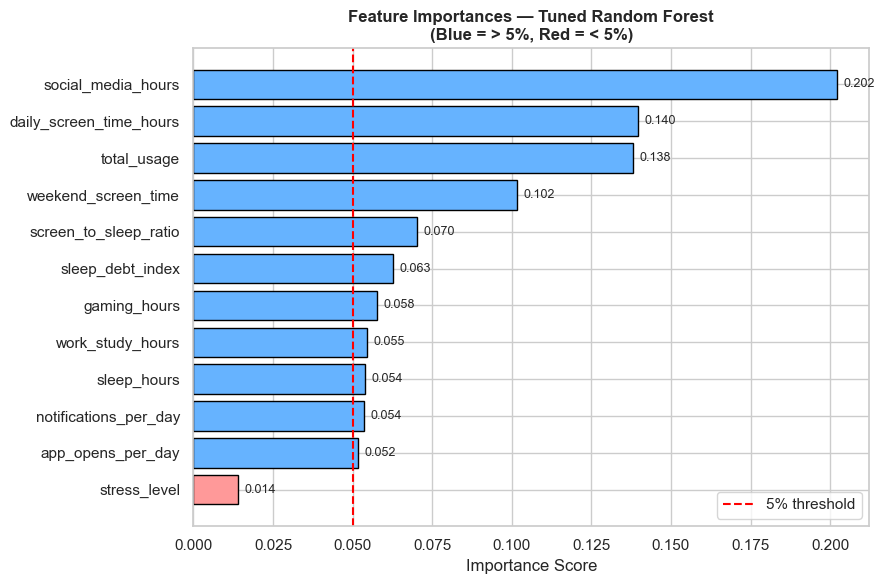


Feature importance ranking:


,Importance
social_media_hours,0.2021
daily_screen_time_hours,0.1396
total_usage,0.1381
weekend_screen_time,0.1017
screen_to_sleep_ratio,0.0703
sleep_debt_index,0.0628
gaming_hours,0.0577
work_study_hours,0.0546
sleep_hours,0.0538
notifications_per_day,0.0537


In [ ]:
clf = best_model.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True)

    bar_colors = ['#ff9999' if v < 0.05 else '#66b3ff' for v in importances]

    plt.figure(figsize=(9, 6))
    bars = plt.barh(importances.index, importances.values,
                    color=bar_colors, edgecolor='black')
    plt.axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='5% threshold')
    for bar, val in zip(bars, importances.values):
        plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
    plt.title(f'Feature Importances — {best_model_name}\n(Blue = > 5%, Red = < 5%)',
              fontsize=12, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('\nFeature importance ranking:')
    display(importances.sort_values(ascending=False).to_frame('Importance').round(4))
else:
    print('Feature importances not available for this model.')

### 📝 Outcome: Feature Importance
This chart answers: **which features did the champion model rely on most?**

Expected findings:
- **`total_usage`** and **`daily_screen_time_hours`** will likely be the top 2 — the most direct behavioral signals
- **`screen_to_sleep_ratio`** and **`sleep_debt_index`** confirm our derived features added real value
- **`stress_level`** should appear in the middle range — contributing meaningfully but not dominating
- **`work_study_hours`** may rank lower — it's important but noisier than pure consumption metrics

If any feature scores below 1% importance, it contributes almost nothing and could be safely removed in a future version without hurting accuracy.

---
## STEP 13: Save Champion Model

In [ ]:
import joblib

feature_list = X_train.columns.tolist()

joblib.dump(best_model,   'smartphone_model_v5.pkl',   compress=3)
joblib.dump(feature_list, 'model_features_v5.pkl')
joblib.dump(label_decode, 'label_decode_v5.pkl')

print('✅ Saved: smartphone_model_v5.pkl')
print('✅ Saved: model_features_v5.pkl')
print('✅ Saved: label_decode_v5.pkl')
print(f'\n🏆 Champion: {best_model_name}')
print(f'   Accuracy:  {final_acc:.4f}')
print(f'   F1-Score:  {final_f1:.4f}')
print(f'   MAE:       {final_mae:.4f}')
print(f'   RMSE:      {final_rmse:.4f}')
print(f'   Features:  {len(feature_list)}')
print()
print('📦 Django Usage:')
print("""
import joblib, pandas as pd

model    = joblib.load('smartphone_model_v5.pkl')
features = joblib.load('model_features_v5.pkl')
decoder  = joblib.load('label_decode_v5.pkl')

# Build input from Django form
user_input = {
    'daily_screen_time_hours': 8,
    'social_media_hours':      3,
    'gaming_hours':            2,
    'work_study_hours':        4,
    'sleep_hours':             5,
    'notifications_per_day':   120,
    'app_opens_per_day':       80,
    'stress_level':            2,  # Low=0, Medium=1, High=2
}

# Auto-compute derived features
user_input['total_usage']           = user_input['daily_screen_time_hours'] + user_input['gaming_hours'] + user_input['social_media_hours']
user_input['screen_to_sleep_ratio'] = user_input['daily_screen_time_hours'] / (user_input['sleep_hours'] + 0.1)
user_input['sleep_debt_index']      = user_input['daily_screen_time_hours'] - user_input['sleep_hours']

# Predict
df_in      = pd.DataFrame([user_input])[features]
prediction = model.predict(df_in)
label      = decoder[prediction[0]]  # 'Mild', 'Moderate', or 'Severe'
print('Predicted addiction level:', label)
""")

✅ Saved: smartphone_model_v5.pkl
✅ Saved: model_features_v5.pkl
✅ Saved: label_decode_v5.pkl

🏆 Champion: Tuned Random Forest
   Accuracy:  0.5647
   F1-Score:  0.5617
   MAE:       0.4353
   RMSE:      0.6598
   Features:  12

📦 Django Usage:

import joblib, pandas as pd

model    = joblib.load('smartphone_model_v5.pkl')
features = joblib.load('model_features_v5.pkl')
decoder  = joblib.load('label_decode_v5.pkl')

# Build input from Django form
user_input = {
    'daily_screen_time_hours': 8,
    'social_media_hours':      3,
    'gaming_hours':            2,
    'work_study_hours':        4,
    'sleep_hours':             5,
    'notifications_per_day':   120,
    'app_opens_per_day':       80,
    'stress_level':            2,  # Low=0, Medium=1, High=2
}

# Auto-compute derived features
user_input['total_usage']           = user_input['daily_screen_time_hours'] + user_input['gaming_hours'] + user_input['social_media_hours']
user_input['screen_to_sleep_ratio'] = user_input['daily_sc